In [38]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Models

In [39]:
import os
import sys
import json
import glob
import yaml
import torch
import zipfile
import warnings
import numpy as np
import torchvision.transforms as T
import torchvision.transforms.functional as f

from tqdm.notebook import tqdm  # Use notebook version for better UI
from PIL import Image

# --- Path Setup ---
# If this notebook is in the 'scripts' folder, uncomment the line below to add parent dir to path
# sys.path.insert(0, os.path.abspath('..')) 


from model.cls_hrnet import get_cls_net
from model.cls_hrnet_l import get_cls_net as get_cls_net_l
from utils.utils_keypoints import KeypointsDB
from utils.utils_lines import LineKeypointsDB
from utils.utils_heatmap import (
    get_keypoints_from_heatmap_batch_maxpool, 
    get_keypoints_from_heatmap_batch_maxpool_l,
    coords_to_dict, 
    complete_keypoints
)
from utils.utils_calib import FramebyFrameCalib


In [40]:
class Config:
    def __init__(self):
        # Paths
        self.root_dir = "/home/yishu/16822/soccernet-calibration-sportlight/data/dataset/"
        self.split = "valid"
        self.cfg = "config/hrnetv2_w48.yaml"
        self.cfg_l = "config/hrnetv2_w48_l.yaml"
        self.weights_kp = "weights/MV_kp"
        self.weights_line = "weights/MV_lines"
        self.save_dir = "inference/inference_3D/inference_sn23/"
        
        # Hardware
        self.cuda = "cuda:0"
        
        # Hyperparameters
        self.kp_th = 0.1611
        self.line_th = 0.3434
        self.max_reproj_err = 57.0
        
        # Toggles
        self.main_cam_only = False
        self.use_gt = False  # Set to True to use ground truth annotations

args = Config()

# Create save directory if it doesn't exist
if not os.path.exists(args.save_dir):
    os.makedirs(args.save_dir)

print(f"Configuration loaded. Saving results to: {args.save_dir}")

Configuration loaded. Saving results to: inference/inference_3D/inference_sn23/


In [41]:
device = torch.device(args.cuda if torch.cuda.is_available() else 'cpu')
transform = T.Resize((540, 960))

model = None
model_l = None

if not args.use_gt:
    print(f"Loading models to {device}...")
    
    # Load Keypoint Model
    cfg = yaml.safe_load(open(args.cfg, 'r'))
    loaded_state = torch.load(args.weights_kp, map_location=device)
    model = get_cls_net(cfg)
    model.load_state_dict(loaded_state)
    model.to(device)
    model.eval()
    
    # Load Line Model
    cfg_l = yaml.safe_load(open(args.cfg_l, 'r'))
    loaded_state_l = torch.load(args.weights_line, map_location=device)
    model_l = get_cls_net_l(cfg_l)
    model_l.load_state_dict(loaded_state_l)
    model_l.to(device)
    model_l.eval()
    
    print("Models loaded successfully.")
else:
    print("Using Ground Truth mode. Skipping model loading.")

Loading models to cuda:0...
Models loaded successfully.


## Inference!!!

In [5]:
# Load file list
files = glob.glob(os.path.join(args.root_dir + args.split, "*.jpg"))

# Filter for Main Camera only if requested
if args.main_cam_only:
    match_info_path = args.root_dir + args.split + '/match_info_cam_gt.json'
    if os.path.exists(match_info_path):
        cam_info = json.load(open(match_info_path))
        files = [file for file in files if file.split('/')[-1] in cam_info.keys()]
        files = [file for file in files if cam_info[file.split('/')[-1]]['camera'] == 'Main camera center']
    else:
        print(f"Warning: {match_info_path} not found. Skipping Main Camera filtering.")

# Define Zip File Names
if args.main_cam_only:
    zip_name = args.save_dir + args.split + '_main.zip'
else:
    zip_name = args.save_dir + args.split + '.zip'

if args.use_gt:
    suffix = '_main_gt.zip' if args.main_cam_only else '_gt.zip'
    zip_name_pred = args.save_dir + args.split + suffix
else:
    suffix = '_main_pred.zip' if args.main_cam_only else '_pred.zip'
    zip_name_pred = args.save_dir + args.split + suffix

print(f"Found {len(files)} images to process.")
print(f"Prediction Zip: {zip_name_pred}")
print(f"GT/Reference Zip: {zip_name}")

Found 3212 images to process.
Prediction Zip: inference/inference_3D/inference_sn23/valid_pred.zip
GT/Reference Zip: inference/inference_3D/inference_sn23/valid.zip


In [8]:
# Initialize calibration object
# Note: Logic slightly differs based on use_gt in original script regarding denormalize=True
if args.use_gt:
    cam = FramebyFrameCalib(960, 540, denormalize=True)
else:
    cam = FramebyFrameCalib(960, 540)

samples = 0
complete = 0

all_kps_gt = []
all_kps_pred = []
all_lines_gt = []
all_lines_pred = []

print("Starting inference...")
# id = 10

for file in tqdm(files, desc="Processing Images"):
    # print(file)
    image = Image.open(file)
    file_name = file.split('/')[-1].split('.')[0]
    samples += 1
    
    final_params_dict = None

    # ------------------ Ground Truth Logic ------------------
    json_path = file.split('.')[0] + ".json"
    f_json = open(json_path)
    data = json.load(f_json)
    

    kp_db = KeypointsDB(data, f.to_tensor(image))
    line_db = LineKeypointsDB(data, f.to_tensor(image))
    
    # Get heatmaps from DB
    heatmaps_gt, _ = kp_db.get_tensor_w_mask()
    heatmaps_gt = torch.tensor(heatmaps_gt).unsqueeze(0)
    
    heatmaps_l_gt = line_db.get_tensor()
    heatmaps_l_gt = torch.tensor(heatmaps_l_gt).unsqueeze(0)
    
    # Extract coords
    kp_coords_gt = get_keypoints_from_heatmap_batch_maxpool(heatmaps_gt[:, :-1, :, :])
    line_coords_gt = get_keypoints_from_heatmap_batch_maxpool_l(heatmaps_l_gt[:, :-1, :, :])
    
    all_kps_gt.append(kp_coords_gt)
    all_lines_gt.append(line_coords_gt)

    kp_dict_gt = coords_to_dict(kp_coords_gt, threshold=0.01)
    lines_dict_gt = coords_to_dict(line_coords_gt, threshold=0.01)
    
    # cam.update(kp_dict, lines_dict)
    # final_params_dict = cam.heuristic_voting()

    # ------------------ Prediction Logic ------------------
    img_tensor = f.to_tensor(image).float().to(device).unsqueeze(0)
    # Resize if necessary
    img_tensor = img_tensor if img_tensor.size()[-1] == 960 else transform(img_tensor)
    b, c, h, w = img_tensor.size()
    
    # Forward pass
    heatmaps = model(img_tensor)
    heatmaps_l = model_l(img_tensor)

    # Extract coords
    kp_coords = get_keypoints_from_heatmap_batch_maxpool(heatmaps[:, :-1, :, :])
    line_coords = get_keypoints_from_heatmap_batch_maxpool_l(heatmaps_l[:, :-1, :, :])
    
    all_kps_pred.append(kp_coords)
    all_lines_pred.append(line_coords)
    
    kp_dict = coords_to_dict(kp_coords, threshold=args.kp_th)
    lines_dict = coords_to_dict(line_coords, threshold=args.line_th)
    
    # # Complete keypoints
    # # kp_dict, lines_dict = complete_keypoints(kp_dict[0], lines_dict[0], w=w, h=h)

    # cam.update(kp_dict, lines_dict)
    # final_params_dict = cam.heuristic_voting(refine_lines=True)

Starting inference...


Processing Images:   0%|          | 0/3212 [00:00<?, ?it/s]

/home/yishu/16822/PnLCalib/utils/utils_geometry.py:40: RuntimeWarning: invalid value encountered in sqrt
  x1 = ((e - b) + np.sqrt((b - e) ** 2 - 4 * c * (a - d))) / (2 * c)
/home/yishu/16822/PnLCalib/utils/utils_geometry.py:41: RuntimeWarning: invalid value encountered in sqrt
  x2 = ((e - b) - np.sqrt((b - e) ** 2 - 4 * c * (a - d))) / (2 * c)
/home/yishu/miniconda3/envs/PnLCalib/lib/python3.9/site-packages/scipy/stats/_stats_mstats_common.py:182: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/home/yishu/miniconda3/envs/PnLCalib/lib/python3.9/site-packages/scipy/stats/_stats_mstats_common.py:196: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/home/yishu/miniconda3/envs/PnLCalib/lib/python3.9/site-packages/scipy/stats/_stats_mstats_common.py:199: RuntimeWarning: invalid value encountered in scalar divide
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)
/home/yishu/16822/PnLCalib/

In [10]:
import pickle as pkl

all_valid_data = {
    'all_kps_gt': all_kps_gt,
    'all_kps_pred': all_kps_pred,
    'all_lines_gt': all_lines_gt,
    'all_lines_pred': all_lines_pred,
}
with open('uncertainty_all.pkl', 'wb') as f:
    pkl.dump(all_valid_data, f)

In [11]:
print(image.size)
print(heatmaps_gt.shape)
print(kp_coords_gt.shape)
print(heatmaps.shape)
print(kp_coords.shape)

print(heatmaps_l_gt.shape)
print(line_coords_gt.shape)
print(heatmaps_l.shape)
print(line_coords.shape)

(960, 540)
torch.Size([1, 58, 270, 480])
torch.Size([1, 57, 1, 3])
torch.Size([1, 58, 270, 480])
torch.Size([1, 57, 1, 3])
torch.Size([1, 24, 270, 480])
torch.Size([1, 23, 2, 3])
torch.Size([1, 24, 270, 480])
torch.Size([1, 23, 2, 3])


- GT key points

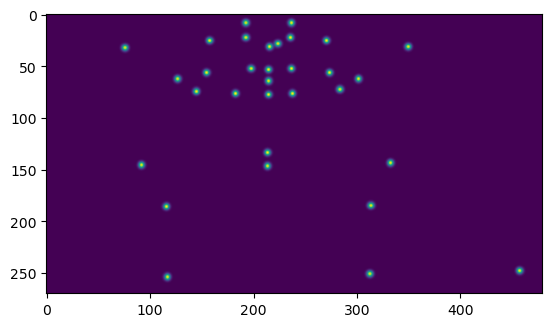

In [12]:
import matplotlib.pyplot as plt 
plt.imshow((heatmaps_gt[0,:-1,:,:].sum(dim=0).cpu().numpy() * 255).astype(np.uint8))

- GT lines

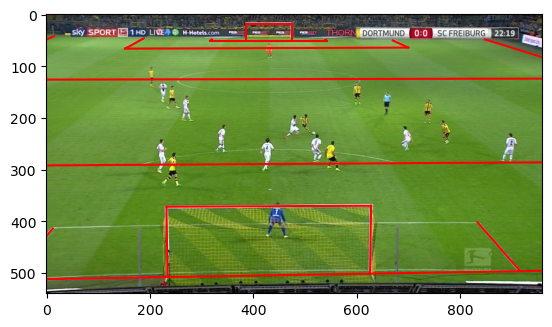

In [13]:
import matplotlib.pyplot as plt 
plt.imshow(image)
for line_idx in range(heatmaps_l_gt.shape[1] - 1):
    # Extract x and y coordinates
    x_coords = line_coords_gt[0, line_idx, :, 0].cpu().numpy()
    y_coords = line_coords_gt[0, line_idx, :, 1].cpu().numpy()
    
    # 'r-' creates a red line. Use 'r-o' if you want to see the endpoints too.
    plt.plot(x_coords, y_coords, 'r-') 

# plt.show()

- Predicted Key points

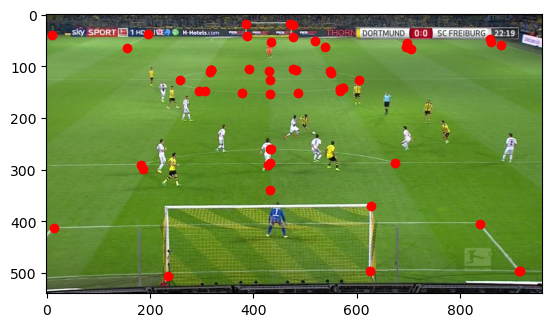

In [14]:
# Plot the keypoints
plt.imshow(image)
for kp in kp_coords[0]:
    if kp[0, 2].item() > 0: #> args.kp_th:
        plt.plot(kp[0, 0].item(), kp[0, 1].item(), 'ro')

Colorbar Range: Min=0.0015, Max=0.8733


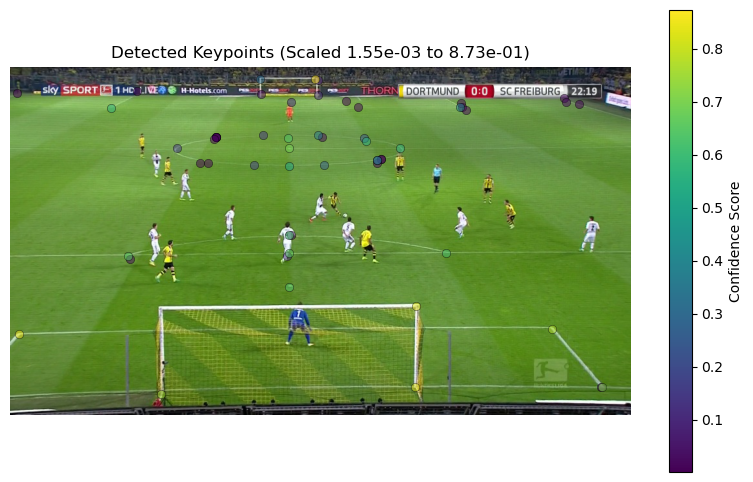

In [15]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

plt.figure(figsize=(10, 6))
plt.imshow(image)

# 1. Collect scores first to determine the range
valid_scores = []
valid_keypoints = []

for kp in kp_coords[0]:
    score = kp[0, 2].item()
    # Apply your threshold here (e.g., > 0.0 or > args.kp_th)
    if score > 0.0:
        valid_scores.append(score)
        valid_keypoints.append(kp)
    
# Sort from low score to high score
valid_keypoints = [kp for _, kp in sorted(zip(valid_scores, valid_keypoints))]
valid_scores = sorted(valid_scores)

# valid_scores = [trust_model.predict(np.array([[score]]))[0] for score in valid_scores]

# 2. Determine Min and Max for the Colorbar
if valid_scores:
    min_score = min(valid_scores)
    max_score = max(valid_scores)
else:
    # Fallback if no points are found
    min_score = 0
    max_score = 1


print(f"Colorbar Range: Min={min_score:.4f}, Max={max_score:.4f}")

# 3. Setup Colormap with dynamic range
cmap = cm.viridis 
norm = mcolors.Normalize(vmin=min_score, vmax=max_score) 

# 4. Plot the points
for kp, score in zip(valid_keypoints, valid_scores):
    x = kp[0, 0].item()
    y = kp[0, 1].item()

    
    color = cmap(norm(score))
    # print(score, norm(score))
    
    plt.plot(x, y, marker='o', color=color, markersize=6, 
             markeredgecolor='black', markeredgewidth=0.5, alpha=0.5)

# 5. Add Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label='Confidence Score')

plt.title(f"Detected Keypoints (Scaled {min_score:.2e} to {max_score:.2e})")
plt.axis('off')
plt.show()

Plotting 57 points. Colorbar Range: 0.0-1.0


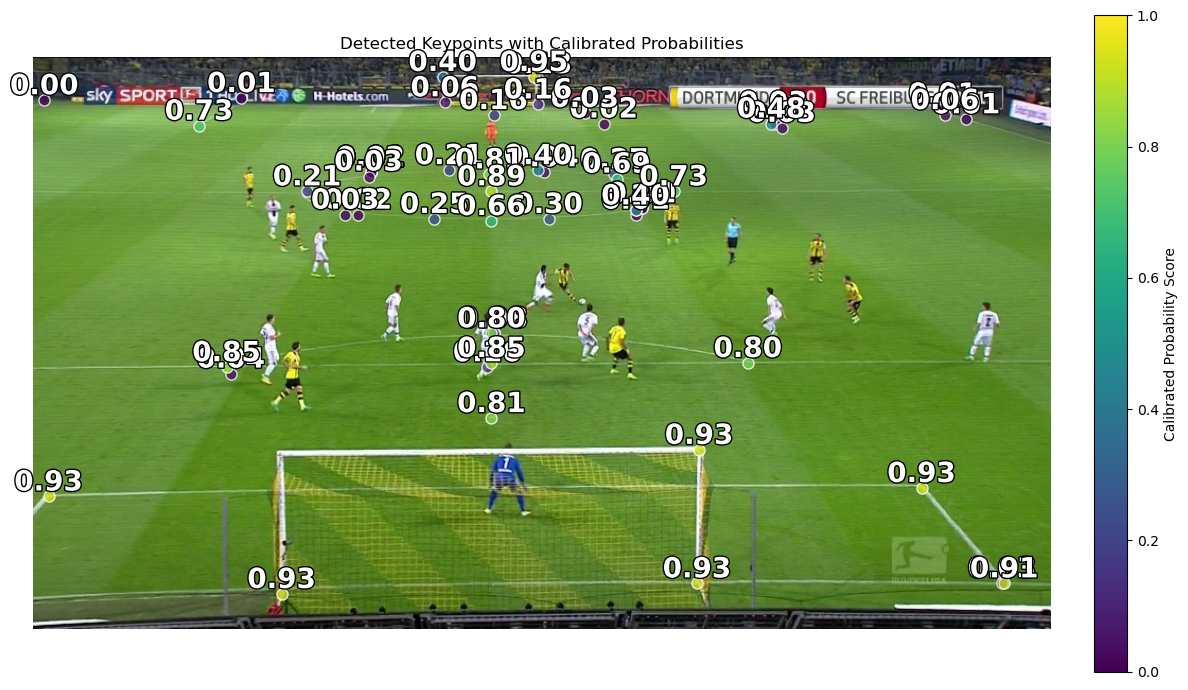

In [31]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe # Import PathEffects for readable text
import numpy as np

# ASSUMPTIONS for this standalone example to run:
# 1. 'image' is defined (e.g., a numpy array representing an image)
# 2. 'kp_coords' is defined (the list of keypoints)
# 3. 'trust_model' is defined and has a .predict() method

plt.figure(figsize=(12, 8)) # Increased size slightly for better text readability
plt.imshow(image)

# 1. Collect and filter valid keypoints
valid_keypoints_data = []

if 'kp_coords' in locals() and len(kp_coords) > 0:
    for kp in kp_coords[0]:
        raw_score = kp[0, 2].item()
        # Apply your threshold here
        if raw_score > 0.0:
            # Store tuple of (raw_score, kp_tensor)
            valid_keypoints_data.append((raw_score, kp))

# Sort by raw score (optional, but keeps plotting order consistent)
valid_keypoints_data.sort(key=lambda x: x[0])

# 2. Setup Colormap
# Assuming calibrated scores are probabilities ranging from 0.0 to 1.0.
# If your calibrated scores have a different range, adjust vmin/vmax accordingly.
norm_min = 0.0
norm_max = 1.0
cmap = cm.viridis
norm = mcolors.Normalize(vmin=norm_min, vmax=norm_max)

print(f"Plotting {len(valid_keypoints_data)} points. Colorbar Range: {norm_min}-{norm_max}")

# 3. Plot the points and text
if 'trust_model' in locals():
    for raw_score, kp in valid_keypoints_data:
        x = kp[0, 0].item()
        y = kp[0, 1].item()

        # Get the calibrated probability
        calib_score = trust_model.predict(np.array([[raw_score]]))[0]
        
        # Determine color based on calibrated score
        color = cmap(norm(calib_score))

        # Plot marker
        plt.plot(x, y, marker='o', color=color, markersize=8,
                 markeredgecolor='white', markeredgewidth=1.0, alpha=0.8)

        # --- ADD THE TEXT LABEL ---
        label_text = f"{calib_score:.2f}"

        # Add text slightly offset from the point
        # ha='center', va='bottom' puts the text just above the point
        txt = plt.text(x, y, label_text, 
                       fontsize=20, 
                       color='white',          # Main text color
                       ha='center', va='bottom',
                       fontweight='bold')

        # Add a black outline (PathEffect) so white text pops on any background
        txt.set_path_effects([pe.withStroke(linewidth=2, foreground='black')])
        # --------------------------

# 4. Add Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.04)
cbar.set_label('Calibrated Probability Score')

plt.title(f"Detected Keypoints with Calibrated Probabilities")
plt.axis('off')
plt.tight_layout()
plt.show()

- Plot the predicted lines


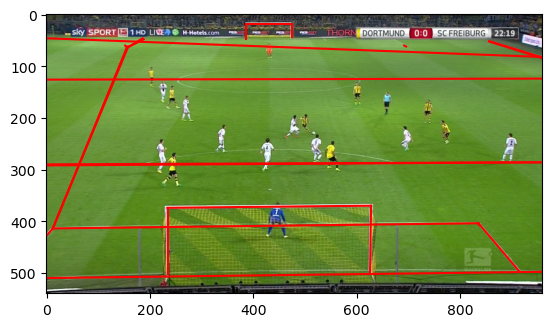

In [17]:
# Plot the keypoints
plt.imshow(image)
for line_coord in line_coords[0]:
    if line_coord[0, 2].item() > 0: #args.line_th:
        plt.plot(line_coord[:, 0], line_coord[:, 1], 'r-')

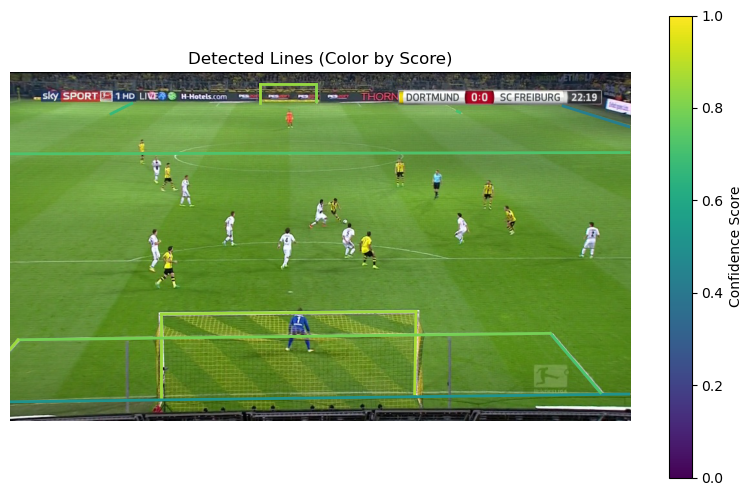

In [18]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# 1. Setup
cmap = cm.viridis 
norm = mcolors.Normalize(vmin=0, vmax=1) 

# Start the plot
plt.figure(figsize=(10, 6))
plt.imshow(image)

# 2. Iterate and plot lines
for line_coord in line_coords[0]:
    score = line_coord[0, 2].item()
    
    if score > args.line_th: #0.0: 
        color = cmap(norm(score))
        plt.plot(line_coord[:, 0], line_coord[:, 1], color=color, linewidth=2)

# 3. Create the mappable for the colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 

# FIX: Explicitly pass the current axes (ax=plt.gca())
plt.colorbar(sm, ax=plt.gca(), label='Confidence Score')

plt.title("Detected Lines (Color by Score)")
plt.axis('off')
plt.show()

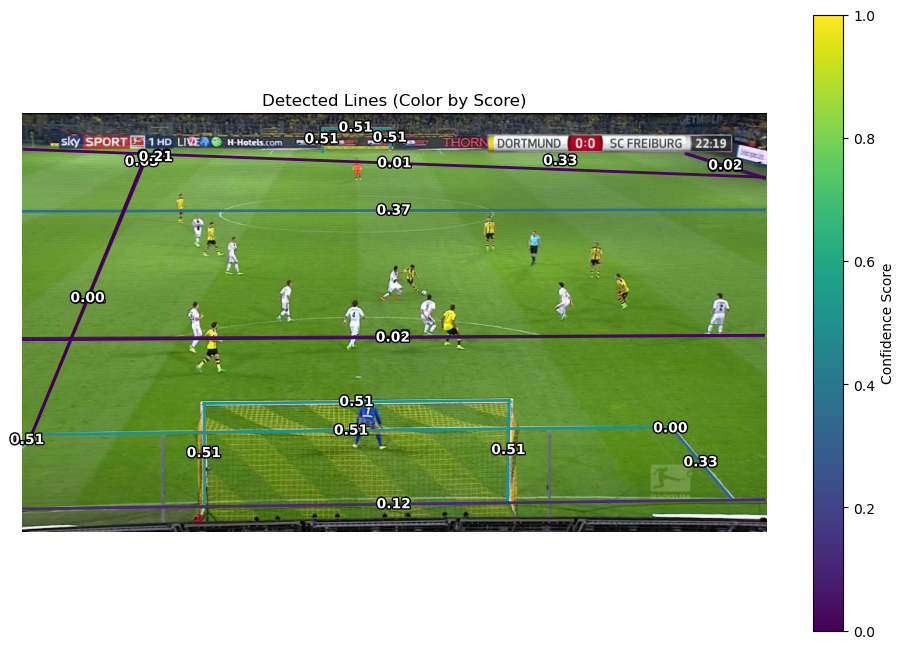

In [32]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe # Import PathEffects

# 1. Setup
cmap = cm.viridis 
norm = mcolors.Normalize(vmin=0, vmax=1) 

plt.figure(figsize=(12, 8))
plt.imshow(image)

# 2. Iterate and plot lines
for line_coord in line_coords[0]:
    raw_score = line_coord[0, 2].item()
    
    if raw_score > 0.0: 
        score = trust_model_line.predict(np.array([[raw_score]]))[0]
        color = cmap(norm(score))
        
        # Extract x and y lists for plotting the segment
        xs = line_coord[:, 0]
        ys = line_coord[:, 1]
        
        plt.plot(xs, ys, color=color, linewidth=2)
        
        # --- ADD TEXT AT MIDPOINT ---
        # 1. Calculate midpoint coordinates
        # We use .item() to ensure we are working with standard Python floats
        x1, y1 = line_coord[0, 0].item(), line_coord[0, 1].item()
        x2, y2 = line_coord[1, 0].item(), line_coord[1, 1].item()
        
        mid_x = (x1 + x2) / 2
        mid_y = (y1 + y2) / 2
        
        # 2. Add the text label
        label_text = f"{score:.2f}"
        
        txt = plt.text(mid_x, mid_y, label_text, 
                       color='white', 
                       fontsize=10, 
                       ha='center', va='center', 
                       fontweight='bold')
        
        # 3. Add black outline for readability
        txt.set_path_effects([pe.withStroke(linewidth=2, foreground='black')])

# 3. Create the mappable for the colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 

plt.colorbar(sm, ax=plt.gca(), label='Confidence Score')

plt.title("Detected Lines (Color by Score)")
plt.axis('off')
plt.show()

## Uncertainty Calibration!!

In [42]:
import pickle as pkl
with open('uncertainty_all.pkl', 'rb') as f:
    all_valid_data = pkl.load(f)
    
all_kps_gt = all_valid_data['all_kps_gt']
all_kps_pred = all_valid_data['all_kps_pred']
all_lines_gt = all_valid_data['all_lines_gt']
all_lines_pred = all_valid_data['all_lines_pred']

In [43]:
all_kps_gt = torch.cat(all_kps_gt, dim=0)
all_kps_pred = torch.cat(all_kps_pred, dim=0)
all_lines_gt = torch.cat(all_lines_gt, dim=0)
all_lines_pred = torch.cat(all_lines_pred, dim=0)
print(all_kps_gt.shape, all_kps_pred.shape, all_lines_gt.shape, all_lines_pred.shape)

torch.Size([3212, 57, 1, 3]) torch.Size([3212, 57, 1, 3]) torch.Size([3212, 23, 2, 3]) torch.Size([3212, 23, 2, 3])


In [44]:
all_kps_gt = all_kps_gt.reshape(-1, 3)
all_kps_pred = all_kps_pred.reshape(-1, 3)
all_lines_gt = all_lines_gt.reshape(-1, 2, 3)
all_lines_pred = all_lines_pred.reshape(-1, 2, 3)

- Point calibration

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression

def train_trustworthiness_model(cal_preds, cal_gt, cal_scores, gt_scores, pixel_threshold=5.0):
    """
    Trains a model to map Raw Scores -> Probability of being within pixel_threshold.
    
    Args:
        cal_preds: (N, 2) array of predicted (x, y)
        cal_gt:    (N, 2) array of GT (x, y)
        cal_scores:(N,) array of raw model scores
        gt_scores: (N,) array of ground truth scores
        pixel_threshold: Max pixel error to be considered "Trustworthy"
        
    Returns:
        iso_reg: Trained regression model
    """
    # 1. Calculate actual pixel errors
    errors = np.linalg.norm(cal_preds - cal_gt, axis=1)
    
    # 2. Create Binary Target (1 = Trustworthy, 0 = Untrustworthy)
    # This is the ground truth for our "Trustworthiness" model
    is_correct = np.logical_and((errors <= pixel_threshold).astype(int), gt_scores > 0.5) # If gt_scores is 0, means that this point is actually not in the image

    # 3. Fit Isotonic Regression (Maps Score -> Probability)
    # We require y_min=0, y_max=1 because it's a probability
    iso_reg = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
    iso_reg.fit(cal_scores, is_correct)
    
    return iso_reg, is_correct

# ==========================================
# 1. TRAINING PHASE (Using Calibration Set)
# ==========================================

# Example parameters
PIXEL_TOLERANCE = 10.0 # Points within 10px are "Good"

calibration_preds = all_kps_pred[:, :2].cpu().numpy()  # Predicted (x, y)
calibration_gt = all_kps_gt[:, :2].cpu().numpy()       # GT (x, y)
calibration_scores = all_kps_pred[:, 2].cpu().numpy()  # Predicted Scores
gt_scores = all_kps_gt[:, 2].cpu().numpy()  # Assuming all GT points are valid for this example

trust_model, is_correct = train_trustworthiness_model(
    calibration_preds,  # Your validation set predictions
    calibration_gt,     # Your validation set GT
    calibration_scores, # Your validation set raw scores
    gt_scores,          # Your validation set GT scores
    pixel_threshold=PIXEL_TOLERANCE
)

- Line calibration

In [54]:
def train_line_trustworthiness_model(cal_preds, cal_gt, cal_scores, gt_scores, pixel_threshold=5.0):
    """
    Trains a model to map Raw Line Scores -> Probability of the line being within pixel_threshold.
    
    Args:
        cal_preds: (N, 2, 2) array of predicted endpoints [(x1, y1), (x2, y2)]
        cal_gt:    (N, 2, 2) array of GT endpoints [(x1, y1), (x2, y2)]
        cal_scores:(N,) array of raw model scores (one score per line)
        gt_scores: (N,) array of ground truth scores (visibility/existence of the line)
        pixel_threshold: Max pixel error allowed for *both* endpoints to be "Trustworthy"
        
    Returns:
        iso_reg: Trained regression model
        is_correct: Boolean array indicating which lines were considered correct
    """
    # 1. Calculate actual pixel errors for both points
    # shape: (N, 2, 2) -> difference in x,y for start and end points
    diffs = cal_preds - cal_gt
    
    # Calculate Euclidean distance for each endpoint
    # shape: (N, 2) -> [error_point_1, error_point_2]
    endpoint_errors = np.linalg.norm(diffs, axis=2)
    
    # 2. Define Line Error
    # We take the MAXIMUM error of the two endpoints. 
    # If point A is perfect but point B is off by 20px, the line is wrong.
    line_max_errors = np.max(endpoint_errors, axis=1)
    
    # 3. Create Binary Target (1 = Trustworthy, 0 = Untrustworthy)
    # The line is correct only if the worst endpoint is still within the threshold
    # AND the ground truth says the line actually exists.
    is_correct = np.logical_and(
        (line_max_errors <= pixel_threshold).astype(int), 
        gt_scores > 0.5
    ) 

    # 4. Fit Isotonic Regression (Maps Score -> Probability)
    iso_reg = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
    iso_reg.fit(cal_scores, is_correct)
    
    return iso_reg, is_correct


PIXEL_TOLERANCE = 20.0 # Points within 10px are "Good"

calibration_preds_line = all_lines_pred[:, :, :2].cpu().numpy()  # Predicted (x, y)
calibration_gt_line = all_lines_gt[:, :, :2].cpu().numpy()       # GT (x, y)
calibration_scores_line = torch.min(all_lines_pred[:, :, 2], dim=1)[0].cpu().numpy()  # Predicted Scores
gt_scores_line = all_lines_gt[:, 0, 2].cpu().numpy()  # Assuming all GT points are valid for this example


trust_model_line, is_correct_line = train_line_trustworthiness_model(
    calibration_preds_line,  # Your validation set predictions
    calibration_gt_line,     # Your validation set GT
    calibration_scores_line, # Your validation set raw scores
    gt_scores_line,          # Your validation set GT scores
    pixel_threshold=PIXEL_TOLERANCE
)


In [63]:
with open('trust_model.pkl', 'wb') as f:
    pkl.dump({
        'keypoint_model': trust_model,
        'line_model': trust_model_line
    }, f)

### Point

- distribution

(183084,) 2.4625317e-06 0.92589504


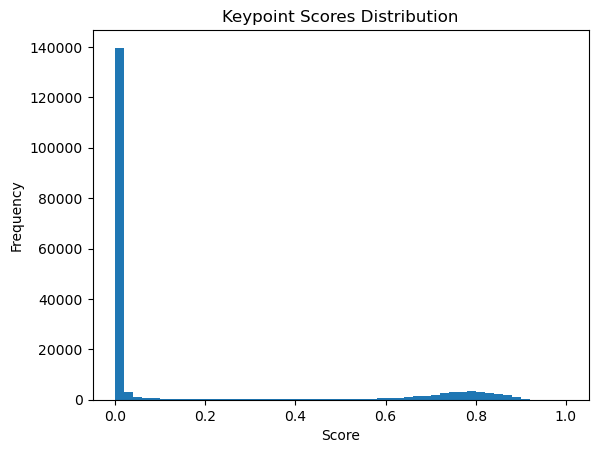

In [55]:
kps_scores = all_kps_pred[:, 2].cpu().numpy()
print(kps_scores.shape, kps_scores.min(), kps_scores.max())
# Plot distribution
plt.hist(kps_scores, bins=50, range=(0, 1))
plt.title("Keypoint Scores Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

- Before calibration

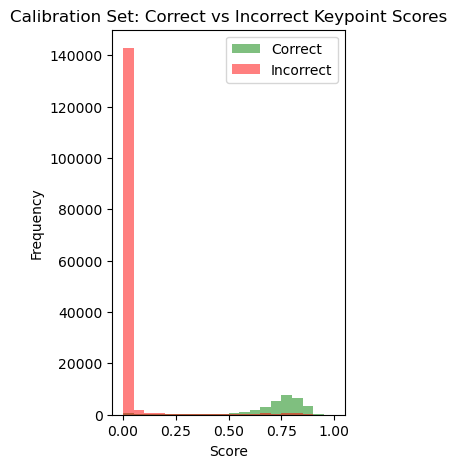

In [56]:
# Plot the correct vs incorrect distribution
plt.figure(figsize=(3, 5))
correct_scores = calibration_scores[is_correct]
incorrect_scores = calibration_scores[~is_correct]
plt.hist(correct_scores, bins=20, range=(0, 1), alpha=0.5, label='Correct', color='g')
plt.hist(incorrect_scores, bins=20, range=(0, 1), alpha=0.5, label='Incorrect', color='r')
plt.title("Calibration Set: Correct vs Incorrect Keypoint Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

- after calibration

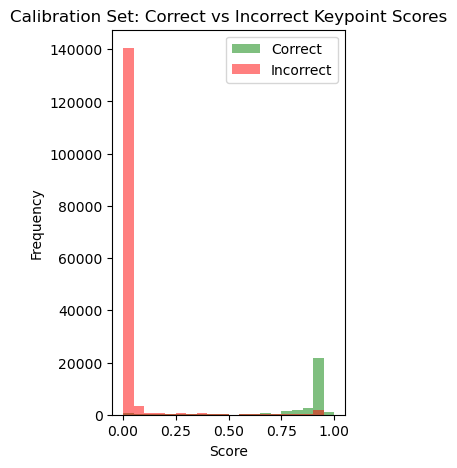

In [57]:
# Plot the correct vs incorrect distribution
plt.figure(figsize=(3, 5))
correct_scores = trust_model.predict(calibration_scores[is_correct])
incorrect_scores = trust_model.predict(calibration_scores[~is_correct])
plt.hist(correct_scores, bins=20, range=(0, 1), alpha=0.5, label='Correct', color='g')
plt.hist(incorrect_scores, bins=20, range=(0, 1), alpha=0.5, label='Incorrect', color='r')
plt.title("Calibration Set: Correct vs Incorrect Keypoint Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

- Fitted Plot

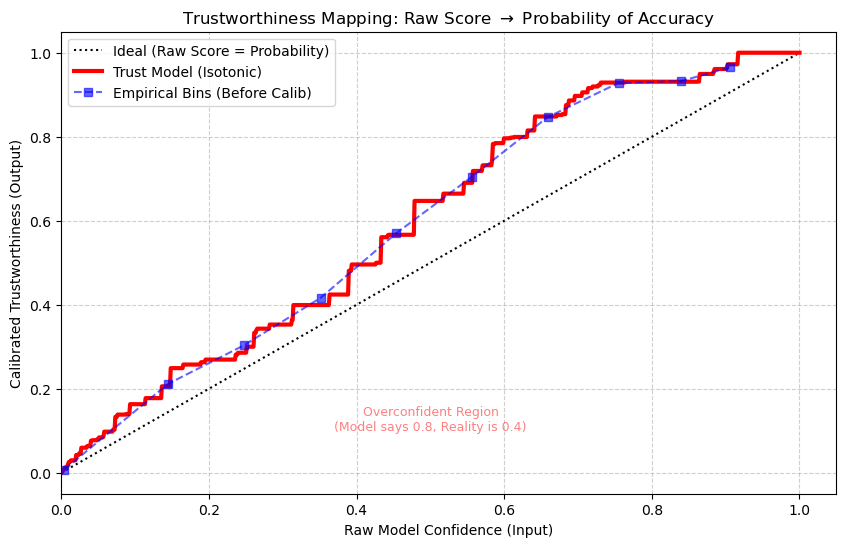

In [58]:
def plot_trust_model(trust_model, cal_scores=None, is_correct=None):
    """
    Plots the calibration curve (Isotonic Regression function) and optionally
    the data distribution used to train it.
    
    Args:
        trust_model: The trained IsotonicRegression object.
        cal_scores: (Optional) The raw scores used for training (for scatter plot).
        is_correct: (Optional) The binary targets (0/1) used for training.
    """
    
    # 1. Generate the curve data
    # Create a smooth range of scores from 0 to 1
    x_range = np.linspace(0, 1, 1000)
    # Ask the model: "If the raw score is X, what is the probability it's correct?"
    y_calibrated = trust_model.predict(x_range)
    
    # 2. Setup Plot
    plt.figure(figsize=(10, 6))
    
    # --- Plot A: The Ideal Line (Perfect Calibration) ---
    plt.plot([0, 1], [0, 1], "k:", label="Ideal (Raw Score = Probability)")
    
    # --- Plot B: Your Trust Model (The Learned Mapping) ---
    plt.plot(x_range, y_calibrated, "r-", linewidth=3, label="Trust Model (Isotonic)")
    
    # --- Plot C: Training Data (Optional) ---
    if cal_scores is not None and is_correct is not None:
        # # Plot the actual 0s (Incorrect) and 1s (Correct) as small dots
        # # We add random jitter to the y-axis so points don't overlap too much
        # jitter = np.random.uniform(-0.02, 0.02, size=len(cal_scores))
        # plt.scatter(cal_scores, is_correct + jitter, 
        #             alpha=0.3, s=10, color='gray', label="Calibration Data Points")
        
        # Optional: Add reliability bins to see the empirical alignment
        # This groups scores into bins (e.g., 0.1-0.2) and calculates the actual accuracy
        try:
            from sklearn.calibration import calibration_curve
            prob_true, prob_pred = calibration_curve(is_correct, cal_scores, n_bins=10)
            plt.plot(prob_pred, prob_true, "s--", color='blue', alpha=0.6, label="Empirical Bins (Before Calib)")
        except ImportError:
            pass

    # 3. Formatting
    plt.title("Trustworthiness Mapping: Raw Score $\\rightarrow$ Probability of Accuracy")
    plt.xlabel("Raw Model Confidence (Input)")
    plt.ylabel("Calibrated Trustworthiness (Output)")
    plt.legend(loc="best")
    plt.grid(True, linestyle="--", alpha=0.6)
    
    # Annotate regions
    plt.text(0.5, 0.1, "Overconfident Region\n(Model says 0.8, Reality is 0.4)", 
             color='red', alpha=0.5, ha='center', fontsize=9, rotation=0)
    
    plt.xlim(0, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.show()

# ==========================================
# Usage
# ==========================================

# Assuming you have the variables from the previous step:
# trust_model, calibration_scores, is_correct

plot_trust_model(trust_model, calibration_scores, is_correct)

In [ ]:
# ==========================================
# 2. INFERENCE PHASE (New Data)
# ==========================================

# Let's say you have raw scores from a new test image
# test_scores = [0.1, 0.4, 0.95, 0.99]
trustworthiness = trust_model.predict(test_scores)

print("Raw Scores:      ", test_scores)
print("Trustworthiness: ", trustworthiness)

# Example Output:
# Raw Scores:       [0.10, 0.40, 0.95, 0.99]
# Trustworthiness:  [0.00, 0.15, 0.60, 0.98]
# Interpretation: Even though 0.95 looks high, the model says 
# "Historically, points with score 0.95 are only correct 60% of the time."

### Line

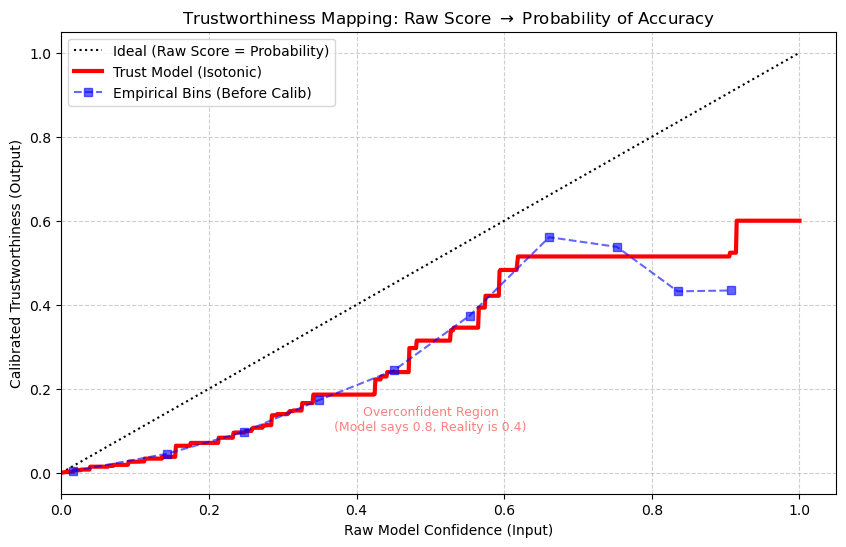

In [59]:
def plot_trust_model(trust_model, cal_scores=None, is_correct=None):
    """
    Plots the calibration curve (Isotonic Regression function) and optionally
    the data distribution used to train it.
    
    Args:
        trust_model: The trained IsotonicRegression object.
        cal_scores: (Optional) The raw scores used for training (for scatter plot).
        is_correct: (Optional) The binary targets (0/1) used for training.
    """
    
    # 1. Generate the curve data
    # Create a smooth range of scores from 0 to 1
    x_range = np.linspace(0, 1, 1000)
    # Ask the model: "If the raw score is X, what is the probability it's correct?"
    y_calibrated = trust_model.predict(x_range)
    
    # 2. Setup Plot
    plt.figure(figsize=(10, 6))
    
    # --- Plot A: The Ideal Line (Perfect Calibration) ---
    plt.plot([0, 1], [0, 1], "k:", label="Ideal (Raw Score = Probability)")
    
    # --- Plot B: Your Trust Model (The Learned Mapping) ---
    plt.plot(x_range, y_calibrated, "r-", linewidth=3, label="Trust Model (Isotonic)")
    
    # --- Plot C: Training Data (Optional) ---
    if cal_scores is not None and is_correct is not None:
        # # Plot the actual 0s (Incorrect) and 1s (Correct) as small dots
        # # We add random jitter to the y-axis so points don't overlap too much
        # jitter = np.random.uniform(-0.02, 0.02, size=len(cal_scores))
        # plt.scatter(cal_scores, is_correct + jitter, 
        #             alpha=0.3, s=10, color='gray', label="Calibration Data Points")
        
        # Optional: Add reliability bins to see the empirical alignment
        # This groups scores into bins (e.g., 0.1-0.2) and calculates the actual accuracy
        try:
            from sklearn.calibration import calibration_curve
            prob_true, prob_pred = calibration_curve(is_correct, cal_scores, n_bins=10)
            plt.plot(prob_pred, prob_true, "s--", color='blue', alpha=0.6, label="Empirical Bins (Before Calib)")
        except ImportError:
            pass

    # 3. Formatting
    plt.title("Trustworthiness Mapping: Raw Score $\\rightarrow$ Probability of Accuracy")
    plt.xlabel("Raw Model Confidence (Input)")
    plt.ylabel("Calibrated Trustworthiness (Output)")
    plt.legend(loc="best")
    plt.grid(True, linestyle="--", alpha=0.6)
    
    # Annotate regions
    plt.text(0.5, 0.1, "Overconfident Region\n(Model says 0.8, Reality is 0.4)", 
             color='red', alpha=0.5, ha='center', fontsize=9, rotation=0)
    
    plt.xlim(0, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.show()

# ==========================================
# Usage
# ==========================================

# Assuming you have the variables from the previous step:
# trust_model, calibration_scores, is_correct

plot_trust_model(trust_model_line, calibration_scores_line, is_correct_line)

- Before Calibration

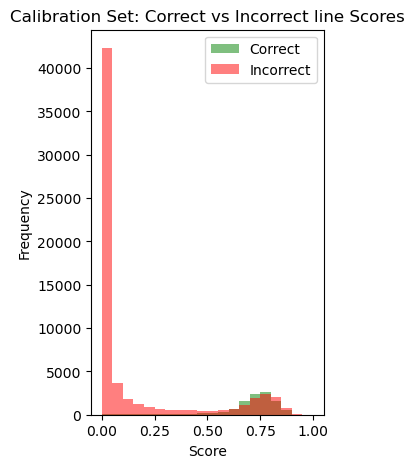

In [60]:
# Plot the correct vs incorrect distribution
plt.figure(figsize=(3, 5))
correct_scores = calibration_scores_line[is_correct_line]
incorrect_scores = calibration_scores_line[~is_correct_line]
plt.hist(correct_scores, bins=20, range=(0, 1), alpha=0.5, label='Correct', color='g')
plt.hist(incorrect_scores, bins=20, range=(0, 1), alpha=0.5, label='Incorrect', color='r')
plt.title("Calibration Set: Correct vs Incorrect line Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

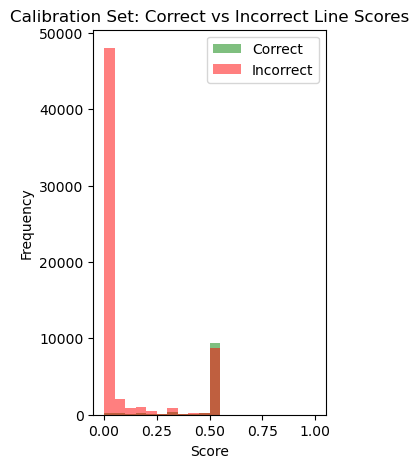

In [62]:
# Plot the correct vs incorrect distribution
plt.figure(figsize=(3, 5))
correct_scores = trust_model_line.predict(calibration_scores_line[is_correct_line])
incorrect_scores = trust_model_line.predict(calibration_scores_line[~is_correct_line])
plt.hist(correct_scores, bins=20, range=(0, 1), alpha=0.5, label='Correct', color='g')
plt.hist(incorrect_scores, bins=20, range=(0, 1), alpha=0.5, label='Incorrect', color='r')
plt.title("Calibration Set: Correct vs Incorrect Line Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()